# Foundation Model: MOMENT — LSST Classification

Three evaluation strategies, in increasing expressiveness:

| Strategy | Backbone | Head | Description |
|---|---|---|---|
| **A. Feature Extraction** | Frozen (embedding mode) | Ridge CV | Pre-trained features → sklearn classifier |
| **B. Linear Probing (frozen backbone, trained head)** | Frozen | Trained | Only classification head learns |
| **C. Full Fine-tuning** | Trained | Trained | All layers adapt to LSST |

**Input format**: MOMENT expects `(batch, n_channels, seq_len)` = `(batch, 6, 36)`.  

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifierCV, LogisticRegressionCV
from sklearn.metrics import f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from momentfm import MOMENTPipeline

from tslearn.datasets import UCR_UEA_datasets

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load Data

In [2]:
ds = UCR_UEA_datasets()
X_train, y_train_raw, X_test, y_test_raw = ds.load_dataset('LSST')

# tslearn returns string labels — encode to contiguous integers
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)
N_CLASSES = len(le.classes_)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')
print(f'Classes ({N_CLASSES}): {le.classes_}')

X_train: (2459, 36, 6)  y_train: (2459,)
X_test:  (2466, 36, 6)   y_test:  (2466,)
Classes (14): ['15' '16' '42' '52' '53' '6' '62' '64' '65' '67' '88' '90' '92' '95']


In [3]:
# mask of samples where NO band is all-zero
valid_mask = ~(X_train == 0).all(axis=1).any(axis=1)
print(f'{valid_mask.sum()} valid samples out of {len(X_train)}')

valid_mask = ~(X_test == 0).all(axis=1).any(axis=1)
print(f'{valid_mask.sum()} valid samples out of {len(X_test)}')

X_test = X_test[valid_mask]
y_test = y_test[valid_mask]

print(f'X_test: {X_test.shape}  y_test: {y_test.shape}')

2459 valid samples out of 2459
2465 valid samples out of 2466
X_test: (2465, 36, 6)  y_test: (2465,)


## 3. Dataset & DataLoaders

MOMENT expects input shape `(batch, n_channels, seq_len)`.  
tslearn returns `(n, seq_len, n_channels)` → we transpose in the Dataset.


In [4]:
class LSSTDataset(Dataset):
    """LSST dataset for MOMENT. Transposes (T, C) → (C, T) for MOMENT input."""

    def __init__(self, X, y):
        # X: (n, T, C) → (n, C, T)
        self.X = torch.from_numpy(X.transpose(0, 2, 1).astype(np.float32))
        self.y = torch.from_numpy(y.astype(np.int64))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128

train_dataset = LSSTDataset(X_train, y_train)
test_dataset  = LSSTDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 4. Utilities

In [5]:
COLORS = [
    "#ca1b46",'#3cb44b','#ffe119','#4363d8','#f58231','#911eb4',
    '#42d4f4','#f032e6','#bfef45','#fabed4','#469990','#dcbeff',
    '#9A6324','#fffac8'
]

results  = {}   # name → {macro_f1, acc}
all_preds = {}  # name → predicted labels on test set


def record(name, y_true, y_pred):
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc      = accuracy_score(y_true, y_pred)
    print(f'{name:45s}  macro-F1={macro_f1:.4f}  acc={acc:.4f}')
    results[name]   = {'macro_f1': macro_f1, 'acc': acc}
    all_preds[name] = y_pred
    return macro_f1, acc


def class_weights_tensor():
    """Balanced class weights as a GPU tensor for CrossEntropyLoss."""
    w = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_train)
    return torch.tensor(w, dtype=torch.float32).to(DEVICE)

## Part A — Linear Probe

Extract fixed representations from the **pre-trained, frozen** MOMENT backbone, then fit a Ridge classifier on top.  
This measures how useful the pre-trained features are.

In [6]:
model_embed = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={"task_name": "embedding"},
)
model_embed.init()
model_embed.to(DEVICE).float()
model_embed.eval()

total = sum(p.numel() for p in model_embed.parameters())
print(f'Total parameters: {total:,}  (all frozen)')

Total parameters: 341,240,320  (all frozen)


### Extract Embeddings

In [7]:
def extract_embeddings(model, loader):
    """Run frozen model and collect embeddings. Returns (n, d_model) array."""
    embeddings, labels = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc='Extracting embeddings'):
            out = model(x_enc=x.to(DEVICE), input_mask=None)
            embeddings.append(out.embeddings.cpu().numpy())
            labels.append(y.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)


Z_train, train_lbl = extract_embeddings(model_embed, train_loader)
Z_test,  test_lbl  = extract_embeddings(model_embed, test_loader)
print(f'Embeddings — train: {Z_train.shape}, test: {Z_test.shape}')

Extracting embeddings: 100%|██████████| 20/20 [00:03<00:00,  6.44it/s]

Embeddings — train: (2459, 1024), test: (2465, 1024)


### Statistical Classifiers

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
Z_train = scaler.fit_transform(Z_train)
Z_test = scaler.transform(Z_test)

In [9]:
ridge_probe = RidgeClassifierCV(
    alphas=np.logspace(-3, 3, 10),
    scoring='f1_macro',
    cv=cv,
    class_weight='balanced'
)
ridge_probe.fit(Z_train, train_lbl)
_, _ = record('RidgeClassifierCV', test_lbl, ridge_probe.predict(Z_test))

RidgeClassifierCV                              macro-F1=0.2887  acc=0.3444


In [10]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=8,
    refit=True,
)

rf_grid.fit(Z_train, train_lbl)
_ = record('RandomForestClassifier', test_lbl, rf_grid.predict(Z_test))

RandomForestClassifier                         macro-F1=0.3065  acc=0.4872


In [11]:
lr = LogisticRegressionCV(
    Cs=np.logspace(-3, 3, 10),
    cv=cv,
    scoring='f1_macro',
    max_iter=5_000,
    class_weight='balanced',
    n_jobs=8,
    refit=True,
    random_state=42,
    use_legacy_attributes=False
)

lr.fit(Z_train, train_lbl)
_ = record('LogisticRegressionCV', test_lbl, lr.predict(Z_test))

LogisticRegressionCV                           macro-F1=0.3882  acc=0.4763


### Embedding Space (PCA)

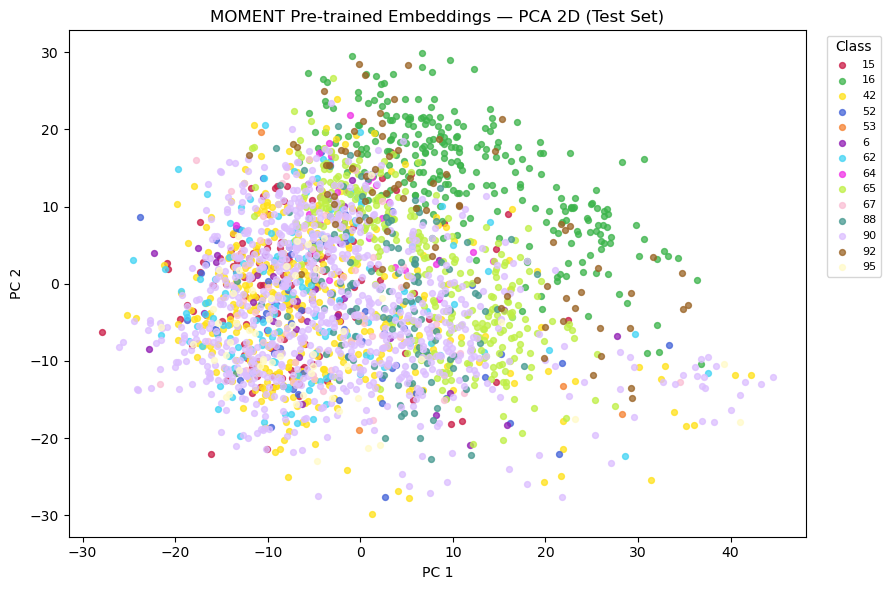

In [12]:
emb_2d = PCA(n_components=2).fit_transform(Z_test)

fig, ax = plt.subplots(figsize=(9, 6))
for i, cls in enumerate(le.classes_):
    mask = test_lbl == i
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=COLORS[i], label=str(cls), s=18, alpha=0.75)
ax.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_title('MOMENT Pre-trained Embeddings — PCA 2D (Test Set)')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
plt.tight_layout()
plt.savefig('figures/moment_embeddings_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## Parts B & C — Fine-tuning

Shared training loop used by both strategies. Uses:
- **Weighted CrossEntropyLoss** — handles 111× class imbalance
- **AdamW** with cosine annealing LR schedule
- **Gradient clipping** (norm ≤ 1.0) — stabilises T5 backbone training
- Best checkpoint selected by macro-F1 on the test set each epoch


In [13]:
def train_moment(model, n_epochs, lr, desc):
    """
    Fine-tune a MOMENT classification model.
    Tracks train/test loss, accuracy, and macro-F1 every epoch.
    Returns (best_test_preds, history_dict).
    """
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor(), label_smoothing=0.1)

    best_f1, best_preds = 0.0, None
    history = {k: [] for k in (
        'train_loss', 'test_loss',
        'train_acc',  'test_acc',
        'train_f1',   'test_f1',
    )}

    for epoch in range(n_epochs):
        # ── Train ──────────────────────────────────────────────────────────────
        model.train()
        total_loss, tr_preds, tr_trues = 0.0, [], []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out  = model(x_enc=x, input_mask=None)
            loss = criterion(out.logits, y)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            tr_preds.append(out.logits.argmax(dim=1).cpu().numpy())
            tr_trues.append(y.cpu().numpy())
        scheduler.step()

        tr_preds   = np.concatenate(tr_preds)
        tr_trues   = np.concatenate(tr_trues)
        train_loss = total_loss / len(train_loader)
        train_acc  = accuracy_score(tr_trues, tr_preds)
        train_f1   = f1_score(tr_trues, tr_preds, average='macro', zero_division=0)

        # ── Evaluate ───────────────────────────────────────────────────────────
        model.eval()
        te_preds, te_trues, te_loss = [], [], 0.0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out    = model(x_enc=x, input_mask=None)
                te_loss += criterion(out.logits, y).item()
                te_preds.append(out.logits.argmax(dim=1).cpu().numpy())
                te_trues.append(y.cpu().numpy())
        te_preds  = np.concatenate(te_preds)
        te_trues  = np.concatenate(te_trues)
        test_loss = te_loss / len(test_loader)
        test_acc  = accuracy_score(te_trues, te_preds)
        test_f1   = f1_score(te_trues, te_preds, average='macro', zero_division=0)

        history['train_loss'].append(train_loss);  history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc);    history['test_acc'].append(test_acc)
        history['train_f1'].append(train_f1);      history['test_f1'].append(test_f1)

        if test_f1 > best_f1:
            best_f1, best_preds = test_f1, te_preds.copy()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'[{desc}] Epoch {epoch+1:3d}/{n_epochs} | '
                  f'loss {train_loss:.4f}/{test_loss:.4f} | '
                  f'acc {train_acc:.4f}/{test_acc:.4f} | '
                  f'F1 {train_f1:.4f}/{test_f1:.4f}  (train/test)')

    print(f'[{desc}] Best test macro-F1: {best_f1:.4f}')
    return best_preds, history

## Part B — Linear Probing

Backbone (patch embedder + T5 encoder) is **frozen**.  
Only the randomly-initialised linear classification head is trained with gradient descent.  
Fast to train; useful when data is scarce or compute is limited.


In [14]:
model_probe = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={
        "task_name": "classification",
        "n_channels": 6,
        "num_class": N_CLASSES,
        "freeze_embedder": True,   # freeze patch embedding
        "freeze_encoder": True,    # freeze T5 transformer
        "freeze_head": False,      # train only the classification head
    },
)
model_probe.init()
model_probe = model_probe.to(DEVICE).float()

trainable = sum(p.numel() for p in model_probe.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_probe.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)')

Trainable: 86,030 / 341,326,350 (0.03%)


In [15]:
pred_probe_ft, hist_probe = train_moment(model_probe, n_epochs=30, lr=1e-3, desc='Linear Probing')
_, _ = record('Linear Probing', test_lbl, pred_probe_ft)

[Linear Probing] Epoch   1/30 | loss 3.3086/4.1435 | acc 0.0106/0.0864 | F1 0.0139/0.0751  (train/test)
[Linear Probing] Epoch   5/30 | loss 2.7710/3.7989 | acc 0.2135/0.1598 | F1 0.2613/0.1813  (train/test)
[Linear Probing] Epoch  10/30 | loss 2.5542/3.7395 | acc 0.2757/0.2276 | F1 0.3315/0.2624  (train/test)
[Linear Probing] Epoch  15/30 | loss 2.4562/3.7581 | acc 0.2948/0.2637 | F1 0.3655/0.2865  (train/test)
[Linear Probing] Epoch  20/30 | loss 2.4506/3.7442 | acc 0.3217/0.2617 | F1 0.3891/0.2892  (train/test)
[Linear Probing] Epoch  25/30 | loss 2.4033/3.7289 | acc 0.3359/0.2686 | F1 0.4000/0.2932  (train/test)
[Linear Probing] Epoch  30/30 | loss 2.4168/3.7295 | acc 0.3351/0.2633 | F1 0.4063/0.2907  (train/test)
[Linear Probing] Best test macro-F1: 0.2988
Linear Probing                                 macro-F1=0.2988  acc=0.2815


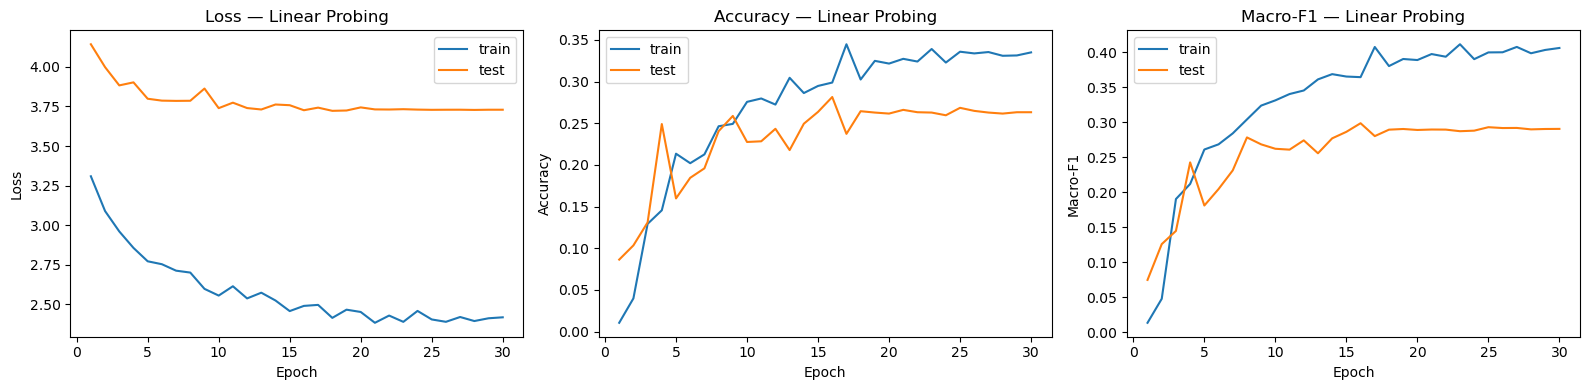

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs = range(1, len(hist_probe['train_loss']) + 1)

axes[0].plot(epochs, hist_probe['train_loss'], label='train')
axes[0].plot(epochs, hist_probe['test_loss'],  label='test')
axes[0].set_title('Loss — Linear Probing'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(epochs, hist_probe['train_acc'], label='train')
axes[1].plot(epochs, hist_probe['test_acc'],  label='test')
axes[1].set_title('Accuracy — Linear Probing'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend()

axes[2].plot(epochs, hist_probe['train_f1'], label='train')
axes[2].plot(epochs, hist_probe['test_f1'],  label='test')
axes[2].set_title('Macro-F1 — Linear Probing'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1'); axes[2].legend()

plt.tight_layout()
plt.savefig('figures/moment_probe_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Part C — Full Fine-tune

All layers (patch embedder, T5 encoder, classification head) are **trainable**.  
Lower learning rate to avoid catastrophic forgetting of pre-trained representations.


In [17]:
model_ft = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={
        "task_name": "classification",
        "n_channels": 6,
        "num_class": N_CLASSES,
        "freeze_embedder": False,
        "freeze_encoder": False,
        "freeze_head": False,
    },
)
model_ft.init()
model_ft = model_ft.to(DEVICE).float()

trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_ft.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)')

Trainable: 341,326,350 / 341,326,350 (100.00%)


In [18]:
pred_ft, hist_ft = train_moment(model_ft, n_epochs=20, lr=1e-4, desc='Full Fine-tuning')
_, _ = record('Fine-tuning', test_lbl, pred_ft)

[Full Fine-tuning] Epoch   1/20 | loss 3.1578/4.0546 | acc 0.0586/0.1286 | F1 0.0730/0.1427  (train/test)
[Full Fine-tuning] Epoch   5/20 | loss 2.0940/3.7101 | acc 0.4221/0.3266 | F1 0.4764/0.3445  (train/test)
[Full Fine-tuning] Epoch  10/20 | loss 1.6469/3.6662 | acc 0.6434/0.3209 | F1 0.7754/0.3435  (train/test)
[Full Fine-tuning] Epoch  15/20 | loss 1.4894/3.6365 | acc 0.7694/0.3590 | F1 0.8779/0.3841  (train/test)
[Full Fine-tuning] Epoch  20/20 | loss 1.4713/3.6324 | acc 0.7731/0.3485 | F1 0.8868/0.3751  (train/test)
[Full Fine-tuning] Best test macro-F1: 0.3953
Fine-tuning                                    macro-F1=0.3953  acc=0.3959


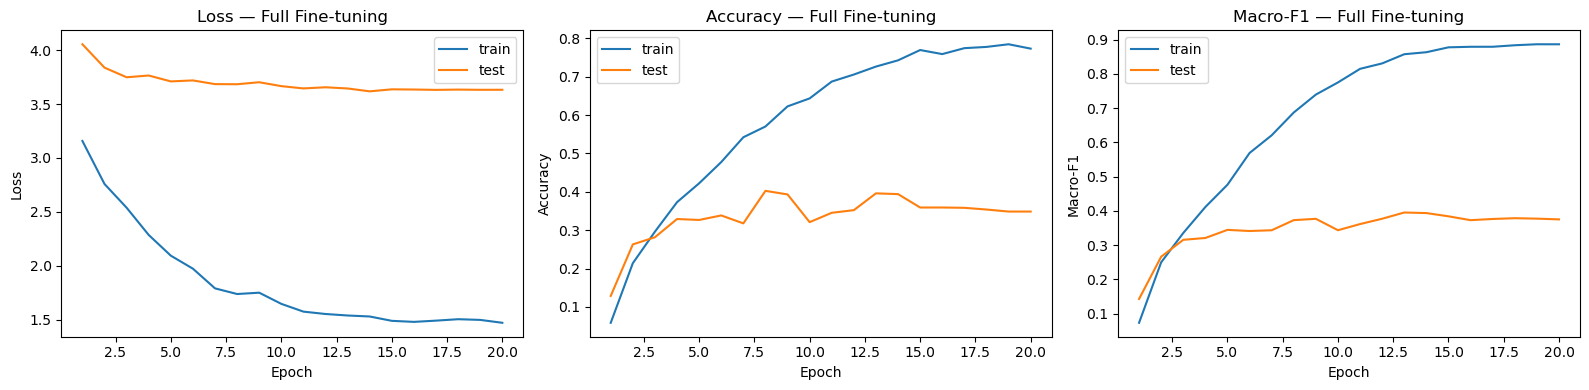

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs = range(1, len(hist_ft['train_loss']) + 1)

axes[0].plot(epochs, hist_ft['train_loss'], label='train')
axes[0].plot(epochs, hist_ft['test_loss'],  label='test')
axes[0].set_title('Loss — Full Fine-tuning'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(epochs, hist_ft['train_acc'], label='train')
axes[1].plot(epochs, hist_ft['test_acc'],  label='test')
axes[1].set_title('Accuracy — Full Fine-tuning'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy'); axes[1].legend()

axes[2].plot(epochs, hist_ft['train_f1'], label='train')
axes[2].plot(epochs, hist_ft['test_f1'],  label='test')
axes[2].set_title('Macro-F1 — Full Fine-tuning'); axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro-F1'); axes[2].legend()

plt.tight_layout()
plt.savefig('figures/moment_fullft_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Attempted Regularisation — Did Not Improve Results

The following modifications were tested to combat overfitting (MOMENT ~300M params, 2 459 training samples) but all led to **worse** test macro-F1 than the plain baseline above:

| Technique | Rationale | Outcome |
|---|---|---|
| **WeightedRandomSampler** | Give each class equal expected frequency per batch to counter 111× imbalance | Degraded performance |
| **Data augmentation** (Gaussian jitter σ=0.05 + random amplitude scale U(0.9,1.1)) | Artificially expand training set, prevent memorisation of exact magnitudes | Degraded performance |
| **Layer-wise LR decay (LLRD)** decay=0.85 | Protect pre-trained T5 weights; head learns fast, bottom layers barely move | Degraded performance |
| **Stronger weight decay** 1e-4 → 0.1 | Stronger L2 to keep large model close to pre-trained prior | Degraded performance |

**Conclusion:** the plain setup (flat AdamW, `weight_decay=1e-4`, standard `CrossEntropyLoss` with class weights, simple shuffle) generalises better on this small dataset. The pre-trained MOMENT features are already strong enough that additional inductive biases interfere more than they help.

## Results Summary

In [20]:
df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Strategy'})
df = df.sort_values('macro_f1', ascending=False)
print(df.to_string(index=False))

              Strategy  macro_f1      acc
           Fine-tuning  0.395251 0.395943
  LogisticRegressionCV  0.388156 0.476268
RandomForestClassifier  0.306543 0.487221
        Linear Probing  0.298831 0.281542
     RidgeClassifierCV  0.288723 0.344422


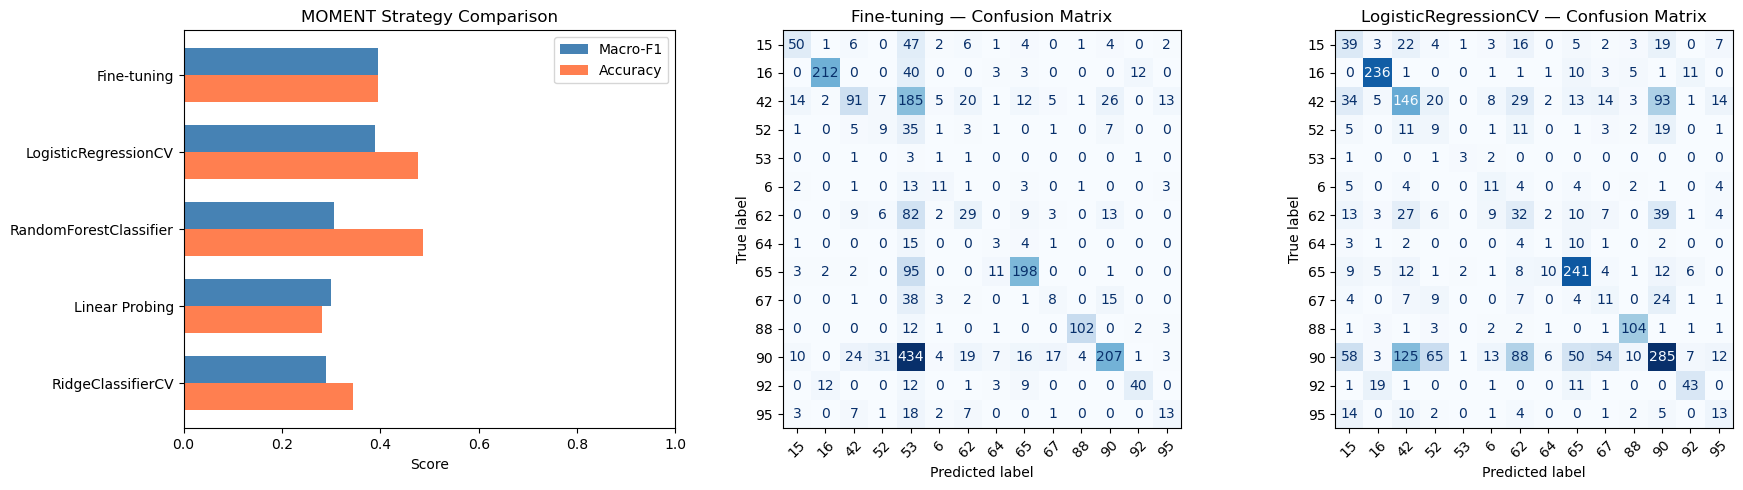

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Horizontal bar chart ───────────────────────────────────────────────────────
names  = df['Strategy'].tolist()
f1s    = df['macro_f1'].tolist()
accs   = df['acc'].tolist()
y      = np.arange(len(names))
height = 0.35

ax = axes[0]
ax.barh(y - height/2, f1s,  height, label='Macro-F1', color='steelblue')
ax.barh(y + height/2, accs, height, label='Accuracy', color='coral')
ax.set_yticks(y)
ax.set_yticklabels([n.split('.')[0] for n in names])
ax.set_xlim(0, 1)
ax.set_xlabel('Score')
ax.set_title('MOMENT Strategy Comparison')
ax.invert_yaxis()
ax.legend()

# ── Confusion matrices (top 2 strategies by macro-F1) ────────────────────────
top2_names = df.sort_values('macro_f1', ascending=False)['Strategy'].head(2).tolist()

for ax, name in zip(axes[1:], top2_names):
    preds = all_preds[name]
    ConfusionMatrixDisplay.from_predictions(
        test_lbl, preds,
        display_labels=le.classes_,
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(f'{name} — Confusion Matrix')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/moment_results.png', dpi=150, bbox_inches='tight')
plt.show()